# Flight Delay Training Pipeline Walkthrough

This notebook shows the training pipeline step by step. It is meant for team members who want to understand what happens without reading all Python modules first.

Goal: classify the departure delay into four classes two hours before departure:

- `no_delay`: delay <= 15 minutes
- `small_delay`: 15 minutes < delay <= 1 hour
- `medium_delay`: 1 hour < delay <= 3 hours
- `large_delay`: delay > 3 hours


## 1. Setup

Run this notebook from the `pipeline/` folder.

In Colab, mount Drive and set `DATA_ROOT` below. If imports fail in Colab, install the needed packages once:

```python
%pip install pandas numpy scikit-learn pyarrow s3fs joblib
```


In [1]:
from pathlib import Path
import os
import sys
import importlib
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
# Make local imports work when the notebook is opened from another folder.
PIPELINE_DIR = Path.cwd()
if not (PIPELINE_DIR / 'loader.py').exists():
    PIPELINE_DIR = Path.cwd() / 'pipeline'

if str(PIPELINE_DIR) not in sys.path:
    sys.path.append(str(PIPELINE_DIR))

from loader import LoaderStorage
from targets import add_delay_class_target, DELAY_CLASS_ORDER
from split import chronological_train_val_test_split
from features import build_feature_matrix, fit_transform, transform, check_columns
from evaluate import evaluate_classifier, classification_report_frame, f1_macro_score, plotConfusionMatrix
from train import TrainingConfig, run_training
import models
importlib.reload(models)
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


In [2]:
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


## 2. Configuration

Only change this cell for normal usage.

Examples:

- Colab/Drive: `DATA_ROOT = "/content/drive/MyDrive/Datamining"`
- S3: `DATA_ROOT = "s3://data-mining"`
- Local folder: `DATA_ROOT = "."`


In [3]:
# Change these paths to your actual dataset location.
DATA_ROOT = "s3://data-mining"
INPUT_PATH = 'data/features/j_all_feature_engineered.parquet'

# Column names used by the current pipeline.
DELAY_COLUMN = 'ArrDelayMinutes'
TIME_COLUMN = 'CRSDepDateTime_UTC'
TARGET_COLUMN = 'delay_class'

# Use a small sample while learning/debugging. Set to 1.0 for the final run.
SAMPLE_FRAC = 0.1

# Good first choices: 'dummy', 'logistic_regression', 'random_forest', 'hist_gradient_boosting', xgboost.
MODEL_NAME = 'xgboost'

OUTPUT_DIR = 'outputs/training_notebook'


## 3. Load The Data

`LoaderStorage` hides whether the file is loaded from local disk, Google Drive, or S3. The rest of the notebook can use the same code for all three.


In [4]:
storage = LoaderStorage(DATA_ROOT)

if INPUT_PATH.endswith('.parquet'):
    df = storage.read_parquet(INPUT_PATH)
elif INPUT_PATH.endswith('.csv'):
    df = storage.read_csv(INPUT_PATH)
else:
    raise ValueError('Use a .parquet or .csv dataset.')

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42)

print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns):,}')
df.head()


Rows: 1,374,009
Columns: 70


,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_7d,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
3911212,282383,2015,12,10,4,WN,MDW,STL,2.0,65.0,...,3.937317,7.071821,2.251701,4.771242,2.723810,5.064815,4.099570,7.683514,5.205105,10.966003
4459140,466622,2016,3,9,3,UA,BWI,DEN,2.0,244.0,...,7.543101,6.857559,7.664234,1.705036,7.150470,11.777090,13.782881,7.513458,12.288438,6.402841
1025292,366057,2014,7,24,4,WN,LAX,BWI,66.0,315.0,...,15.096682,18.962755,21.556231,18.112121,39.753846,17.164179,27.683749,22.679573,23.116625,21.707960
13222014,111313,2019,10,17,4,WN,LGA,ATL,0.0,165.0,...,8.927326,7.315326,15.444444,25.849315,13.698876,11.251656,9.822146,17.213660,12.251337,18.002036
4393157,279116,2016,2,28,7,UA,DEN,LGA,0.0,221.0,...,26.391786,23.419724,2.753036,3.927152,2.504000,7.670391,2.234930,9.053611,4.697328,6.012506


## 4. Create The Target Classes

The raw delay in minutes is converted into the four interval classes. After this step, the model predicts `delay_class`, not the exact number of minutes.


In [5]:
df = add_delay_class_target(
    df,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
)

# Show the class balance. This is important because large delays are usually rare.
class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(DELAY_CLASS_ORDER, fill_value=0)
    .to_frame(name='count')
)

class_distribution['share'] = class_distribution['count'] / len(df)
# expected amount in the test set (20% of the data)
class_distribution['expected_in_test'] = class_distribution['count'] * 0.15
display(class_distribution)

,count,share,expected_in_test
delay_class,,,
no_delay,1110286,0.808063,166542.90
small_delay,179708,0.130791,26956.20
medium_delay,70759,0.051498,10613.85
large_delay,13256,0.009648,1988.40


In [6]:
# display all the records, that are in the Large delay class
display(df[df["delay_class"] == 'large_delay'])

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay,delay_class
12867828,340198,2019,8,27,2,AS,SFO,SEA,239.0,145.0,...,15.862756,9.942257,15.563739,12.979522,17.408451,11.384615,16.372460,10.600793,28.482183,large_delay
219873,286855,2014,2,18,2,UA,IAH,LGA,187.0,205.0,...,15.958450,12.751479,7.281690,18.442857,6.674242,24.716961,8.041225,15.174671,8.764310,large_delay
848868,44394,2014,6,21,6,AA,ORD,TPA,208.0,150.0,...,15.815566,18.369338,16.886957,19.142857,17.536842,24.868805,12.691983,15.593617,18.835317,large_delay
9657989,108525,2018,5,15,2,WN,LGA,ATL,325.0,160.0,...,9.321444,26.973684,3.595000,14.120614,5.624146,26.426619,7.989807,25.152908,6.162266,large_delay
820823,198272,2014,6,16,1,WN,SAN,SFO,308.0,90.0,...,17.630509,12.014085,24.269504,23.004149,20.125000,14.696265,32.834783,11.913539,27.211069,large_delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588424,278784,2019,12,9,1,B6,EWR,MCO,687.0,178.0,...,9.991204,10.780612,71.353846,2.673554,24.803213,9.541860,94.456019,7.082486,33.514239,large_delay
5299818,86049,2016,7,13,3,AA,ORD,STL,183.0,73.0,...,16.344354,23.038674,39.626374,12.350000,23.808333,12.543022,15.714212,10.376170,18.775223,large_delay
10446336,382403,2018,9,4,2,UA,EWR,FLL,198.0,173.0,...,16.169381,17.963918,15.070000,15.088235,8.949640,34.546789,35.679603,19.713345,16.591269,large_delay
1905382,89960,2015,1,8,4,DL,ORD,ATL,751.0,124.0,...,10.084395,35.828794,14.223684,9.432642,6.601329,10.214404,4.492308,16.845874,12.441359,large_delay


In [7]:
# check if all expected Columsn are present, and what unexpected ones we have.
# drop the Unnamed:0 column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
check_columns(df)


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'hist_airline_delay_30d', 'hist_origin_delay_30d', '2h_prev_avg_delay_so_far_day', '2h_prev_cum_count_so_far_day', 'hist_airline_delay', 'hist_dest_delay_7d', 'hist_origin_delay_7d', 'hist_dest_delay_30d', '2h_prev_flights_so_far_day', 'hist_dest_delay', 'hist_origin_delay', '2h_prev_cum_cancelled_so_far_day', 'hist_airline_delay_7d'}


In [8]:
display(pd.Series(df.dtypes))

Year                          int64
Month                         int64
DayofMonth                    int64
DayOfWeek                     int64
Reporting_Airline            object
                             ...   
airline_yesterday_delay     float64
airline_lastweek_delay      float64
global_yesterday_delay      float64
global_lastweek_delay       float64
delay_class                category
Length: 70, dtype: object

## 5. Chronological Train / Validation / Test Split

For a forecasting-like task, we should not randomly mix old and future flights. The model trains on older flights and is evaluated on later flights.

- Train: first 70% of time
- Validation: next 15%
- Test: final 15%


In [9]:
train_df, val_df, test_df = chronological_train_val_test_split(
    df,
    time_column=TIME_COLUMN,
)

print(f'Train rows:      {len(train_df):,}')
print(f'Validation rows: {len(val_df):,}')
print(f'Test rows:       {len(test_df):,}')

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'start': [train_df[TIME_COLUMN].min(), val_df[TIME_COLUMN].min(), test_df[TIME_COLUMN].min()],
    'end': [train_df[TIME_COLUMN].max(), val_df[TIME_COLUMN].max(), test_df[TIME_COLUMN].max()],
    'rows': [len(train_df), len(val_df), len(test_df)],
})
# drop the time column to avoid data leakage. We will use it later to check the chronological order of the splits.
train_df = train_df.drop(columns=[TIME_COLUMN])
val_df = val_df.drop(columns=[TIME_COLUMN])
test_df = test_df.drop(columns=[TIME_COLUMN])

Train rows:      961,806
Validation rows: 206,101
Test rows:       206,102


## 6. Build Features

This step separates `X` and `y`:

- `X`: the input columns the model is allowed to use
- `y`: the delay class the model should learn to predict

The helper also drops obvious leakage columns like actual delay, actual departure time, actual arrival time, etc.


In [10]:
X_train, y_train = fit_transform(train_df, scale="minmax") # alternatively "standard"
X_val, y_val = transform(val_df)
X_test, y_test = transform(test_df)



print(f'Number of model features: {len(X_train.columns):,}')
X_train.head()
# plot a cross correlation matrix of the features

# for every picture, save a violin plot of the feature distribution for each class


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'hist_airline_delay_30d', 'hist_origin_delay_30d', '2h_prev_avg_delay_so_far_day', '2h_prev_cum_count_so_far_day', 'hist_airline_delay', 'hist_dest_delay_7d', 'hist_origin_delay_7d', 'hist_dest_delay_30d', '2h_prev_flights_so_far_day', 'hist_dest_delay', 'hist_origin_delay', '2h_prev_cum_cancelled_so_far_day', 'hist_airline_delay_7d'}
Number of model features: 133


,Year,Month,DayofMonth,DayOfWeek,CRSElapsedTime,Distance,DistanceGroup,CRSDepDateTime,CRSArrDateTime,DayOfYear,...,Dest_ORD,Dest_PDX,Dest_PHL,Dest_PHX,Dest_SAN,Dest_SEA,Dest_SFO,Dest_SLC,Dest_STL,Dest_TPA
0,2014,1,1,3,239.0,0.267729,6,0.218359,0.342837,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,1,1,3,172.0,0.158798,4,0.220445,0.298331,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014,1,1,3,150.0,0.173104,4,0.228790,0.333102,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014,1,1,3,205.0,0.223176,5,0.242698,0.343533,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,1,1,3,97.0,0.057020,2,0.249652,0.317107,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
y_train.head()

0    0
1    2
2    0
3    0
4    0
Name: delay_class, dtype: int64

## 7. Train A Simple Baseline

Always train a baseline first. If a complex model does not beat this, something is wrong or the features are weak.


In [12]:
baseline = make_model('dummy')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
display(pd.Series(baseline_metrics, name='baseline_validation_metrics'))

class_distribution = (
    y_train
    .value_counts()
    .to_frame(name='count')
)
display(class_distribution)

F1-macro: 0.2230
F2-macro: 0.2384


accuracy             0.804883
balanced_accuracy    0.250000
macro_f1             0.222974
macro_f2             0.238440
weighted_f1          0.717871
Name: baseline_validation_metrics, dtype: float64

,count
delay_class,
0,780587
1,125382
2,47506
3,8331


In [13]:
baseline = make_model('Baseline')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
pd.Series(baseline_metrics, name='baseline_validation_metrics')


Distribution of predicted classes based on the 2h_prev_avg_delay_so_far_day feature:
2h_prev_avg_delay_so_far_day
0    925518
1     35303
2       967
3        18
Name: count, dtype: int64
F1-macro: 0.2536
F2-macro: 0.2578


accuracy             0.789900
balanced_accuracy    0.263167
macro_f1             0.253551
macro_f2             0.257765
weighted_f1          0.728291
Name: baseline_validation_metrics, dtype: float64

## 8. Train The Selected Model

Now train the model chosen in the configuration cell. For large datasets, start with a small sample and only later set `SAMPLE_FRAC = 1.0`.


In [14]:
import inspect
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import numpy as np




class_weight_dict = {0: 0.3,
                     1: 0.7,
                     2: 1.1,
                     3: 1.5}
sample_weights = compute_sample_weight(class_weight=class_weight_dict, y=y_train)

model = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)

model.fit(X_train, y_train,sample_weight=sample_weights)
val_metrics, val_predictions = evaluate_classifier(model, X_test, y_test)
pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics')


F1-macro: 0.5016
F2-macro: 0.4788


accuracy             0.824218
balanced_accuracy    0.467293
macro_f1             0.501568
macro_f2             0.478822
weighted_f1          0.802635
Name: xgboost_validation_metrics, dtype: float64

In [15]:
# model = make_neural_network_model(input_shape=X_train.shape[1], num_classes=len(DELAY_CLASS_ORDER))
# # fit_model_with_class_weights(model, X_train, y_train)
# hist =model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_val, y_val),sample_weight=sample_weights,shuffle=True)
# f1_macro = f1_macro_score(model, X_val, y_val)
# print(f"Validation f1-macro score: {f1_macro:.4f}")
# val_metrics, neuralNetwork_predictions = evaluate_classifier(model, X_test, y_test)
# pd.Series(val_metrics, name=f'NN_validation_metrics')

# # plot the training history
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# hist_df = pd.DataFrame(hist.history)
# axes[0].plot(hist.history["loss"], label="Training Loss")
# axes[0].plot(hist.history["val_loss"], label="Validation Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
# axes[0].legend()



# axes[1].plot(hist.history["f1_score"], label="Training F1-Score")
# axes[1].plot(hist.history["val_f1_score"], label="Validation F1-Score")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("F1-Score")
# axes[1].legend()

# axes[2].plot(hist.history["accuracy"], label="Training Accuracy")
# axes[2].plot(hist.history["val_accuracy"], label="Validation Accuracy")
# axes[2].set_xlabel("Epoch")
# axes[2].set_ylabel("Accuracy")
# axes[2].legend()
# plt.tight_layout()
# plt.show()

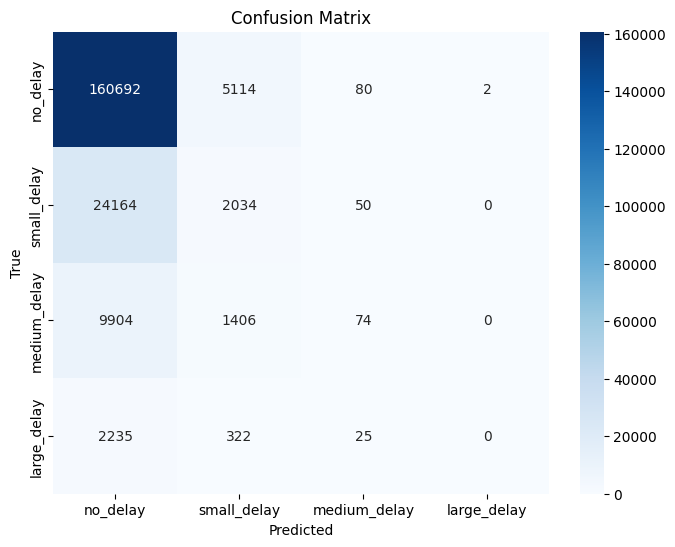

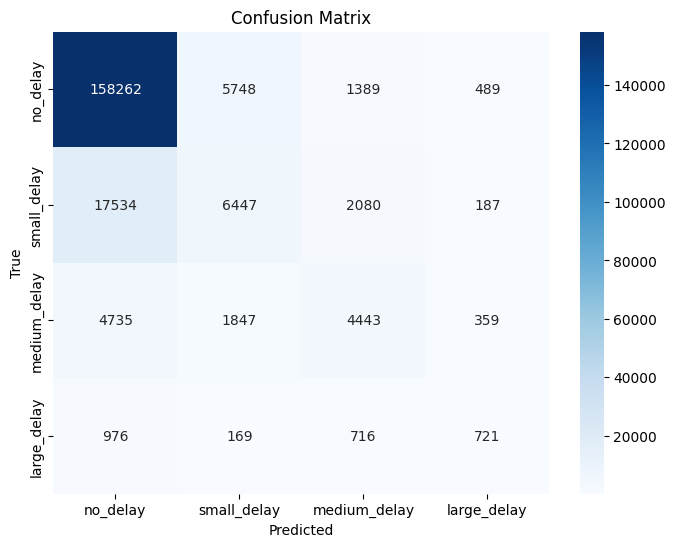

In [16]:
# plot baseline confusion matrix
plotConfusionMatrix(predictions=baseline_predictions, y_true=y_test)
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)


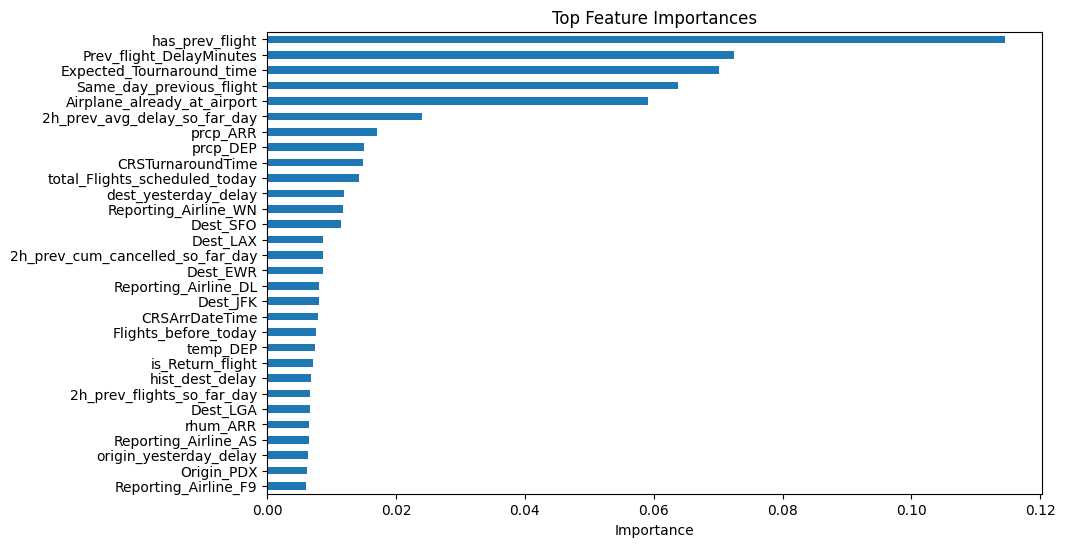

has_prev_flight                     0.114577
Prev_flight_DelayMinutes            0.072509
Expected_Tournaround_time           0.070147
Same_day_previous_flight            0.063767
Airplane_already_at_airport         0.059187
                                      ...   
Dest_IAH                            0.001445
Origin_STL                          0.001406
Dest_TPA                            0.001311
Time_since_last_certified_record    0.000000
FirstFlightRecord                   0.000000
Length: 133, dtype: float32

In [17]:
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=30)
display(feature_importances)

F1-macro: 0.4648
F2-macro: 0.4236


accuracy             0.835654
balanced_accuracy    0.407912
macro_f1             0.464770
macro_f2             0.423643
weighted_f1          0.796521
Name: xgboost_validation_metrics, dtype: float64

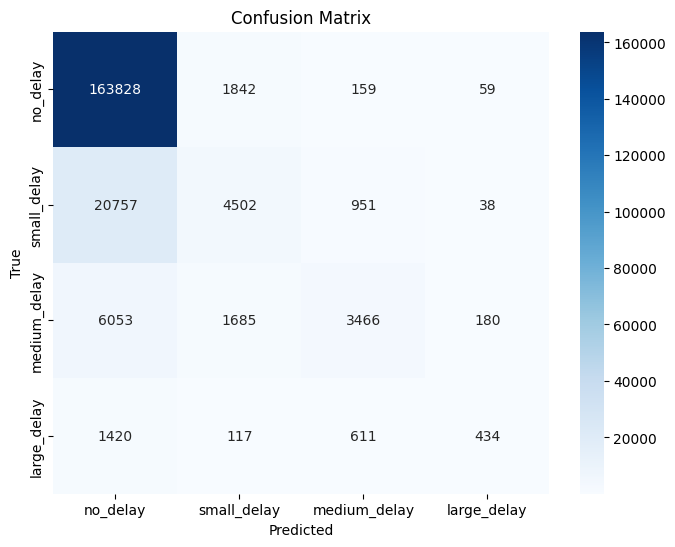

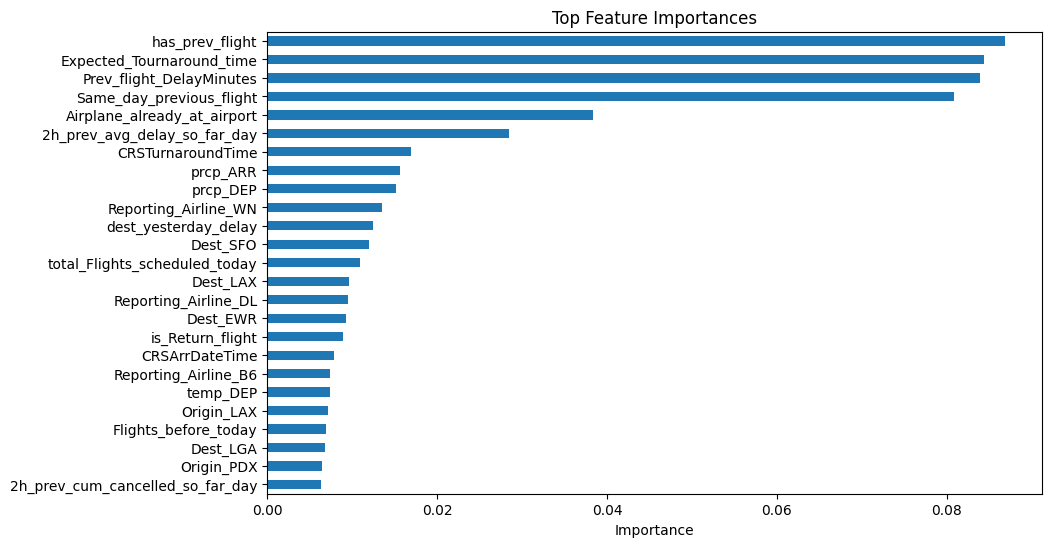

In [18]:
# without class weights
model2 = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)
model2.fit(X_train, y_train)
val_metrics, val_predictions = evaluate_classifier(model2, X_test, y_test)
display(pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics'))
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model2, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=25)

In [19]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')

F1-macro: 0.5016
F2-macro: 0.4788


0    {'accuracy': 0.824218105598199, 'balanced_accu...
1    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

## 9. Final Test Evaluation

Only use the test set after choosing a model. This gives the honest final estimate for the report.


In [20]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')


F1-macro: 0.5016
F2-macro: 0.4788


0    {'accuracy': 0.824218105598199, 'balanced_accu...
1    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

In [21]:
# Per-class report. Look especially at recall for medium_delay and large_delay.
classification_report_frame(model, X_test, y_test)


,precision,recall,f1-score,support
no_delay,0.871933,0.954029,0.911136,165888.000000
small_delay,0.453663,0.245619,0.318693,26248.000000
medium_delay,0.514951,0.390285,0.444034,11384.000000
large_delay,0.410592,0.279241,0.332411,2582.000000
accuracy,0.824218,0.824218,0.824218,0.824218
macro avg,0.562785,0.467293,0.501568,206102.000000
weighted avg,0.793167,0.824218,0.802635,206102.000000


## 10. Persist Run Information

Run this cell after training a model manually in the notebook. It creates one folder for the run and saves the model, run metadata, train/validation/test metrics, overfitting gaps, classification reports, confusion matrix images, and feature importance images when available.


In [22]:
from datetime import datetime, timezone
import json
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def make_json_safe(value):
    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [make_json_safe(item) for item in value]
    if isinstance(value, pd.Series):
        return make_json_safe(value.to_dict())
    if isinstance(value, pd.DataFrame):
        return make_json_safe(value.to_dict(orient="index"))
    if isinstance(value, np.ndarray):
        return make_json_safe(value.tolist())
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if hasattr(value, "isoformat"):
        return value.isoformat()
    try:
        json.dumps(value)
        return value
    except TypeError:
        return str(value)

def save_confusion_matrix_image(predictions, y_true, path, title):
    cm = confusion_matrix(y_true=y_true, y_pred=predictions, labels=range(len(DELAY_CLASS_ORDER)))
    fig, ax = plt.subplots(figsize=(8, 6))
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DELAY_CLASS_ORDER)
    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def save_feature_importance_image(feature_importances, path, top_n=30):
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importances.head(top_n).plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} Feature Importances")
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def metric_gaps(train_metrics, validation_metrics, test_metrics):
    gaps = {}
    for metric_name, train_value in train_metrics.items():
        if metric_name in validation_metrics:
            gaps[f"train_minus_validation_{metric_name}"] = train_value - validation_metrics[metric_name]
        if metric_name in test_metrics:
            gaps[f"train_minus_test_{metric_name}"] = train_value - test_metrics[metric_name]
    return gaps

run_timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_id = f"{run_timestamp}_{MODEL_NAME}"
run_dir = Path(OUTPUT_DIR) / "runs" / run_id
images_dir = run_dir / "images"
run_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

train_metrics, train_predictions = evaluate_classifier(model, X_train, y_train)
validation_metrics, validation_predictions = evaluate_classifier(model, X_val, y_val)
test_metrics, test_predictions = evaluate_classifier(model, X_test, y_test)

train_report = classification_report_frame(model, X_train, y_train)
validation_report = classification_report_frame(model, X_val, y_val)
test_report = classification_report_frame(model, X_test, y_test)
train_report.to_csv(run_dir / "classification_report_train.csv")
validation_report.to_csv(run_dir / "classification_report_validation.csv")
test_report.to_csv(run_dir / "classification_report_test.csv")

saved_images = {}
save_confusion_matrix_image(train_predictions, y_train, images_dir / "train_confusion_matrix.png", "Train Confusion Matrix")
saved_images["train_confusion_matrix"] = "images/train_confusion_matrix.png"
save_confusion_matrix_image(validation_predictions, y_val, images_dir / "validation_confusion_matrix.png", "Validation Confusion Matrix")
saved_images["validation_confusion_matrix"] = "images/validation_confusion_matrix.png"
save_confusion_matrix_image(test_predictions, y_test, images_dir / "test_confusion_matrix.png", "Test Confusion Matrix")
saved_images["test_confusion_matrix"] = "images/test_confusion_matrix.png"

try:
    run_feature_importances = get_feature_importances(model, feature_names=X_train.columns)
except Exception as exc:
    run_feature_importances = pd.Series({"error": str(exc)})
if isinstance(run_feature_importances, pd.Series) and not run_feature_importances.empty and "error" not in run_feature_importances.index:
    save_feature_importance_image(run_feature_importances, images_dir / "feature_importances_top_30.png", top_n=30)
    saved_images["feature_importances_top_30"] = "images/feature_importances_top_30.png"

joblib.dump(model, run_dir / "model.joblib")
(run_dir / "features.json").write_text(json.dumps(list(X_train.columns), indent=2), encoding="utf-8")

run_info = {
    "run_id": run_id,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "data": {
        "data_root": DATA_ROOT,
        "input_path": INPUT_PATH,
        "sample_frac": SAMPLE_FRAC,
        "target_column": TARGET_COLUMN,
        "delay_column": DELAY_COLUMN,
        "time_column": TIME_COLUMN,
    },
    "splits": {
        "train_rows": len(X_train),
        "validation_rows": len(X_val),
        "test_rows": len(X_test),
    },
    "features": {"count": X_train.shape[1], "names": list(X_train.columns)},
    "target_classes": list(DELAY_CLASS_ORDER),
    "artifacts": {
        "model_path": "model.joblib",
        "run_info_path": "run_info.json",
        "features_path": "features.json",
        "train_report_path": "classification_report_train.csv",
        "validation_report_path": "classification_report_validation.csv",
        "test_report_path": "classification_report_test.csv",
        "images": saved_images,
    },
    "model": {
        "name": MODEL_NAME,
        "class_name": type(model).__name__,
        "parameters": model.get_params(deep=False) if hasattr(model, "get_params") else {},
        "class_weights": globals().get("class_weight_dict"),
    },
    "metrics": {
        "train": train_metrics,
        "validation": validation_metrics,
        "test": test_metrics,
        "overfit_gaps": metric_gaps(train_metrics, validation_metrics, test_metrics),
        "train_classification_report": train_report,
        "validation_classification_report": validation_report,
        "test_classification_report": test_report,
    },
    "feature_importances_top_30": run_feature_importances.head(30),
}

run_info_path = run_dir / "run_info.json"
run_info_path.write_text(json.dumps(make_json_safe(run_info), indent=2), encoding="utf-8")
print(f"Persisted run folder: {run_dir}")
run_dir


F1-macro: 0.5942
F2-macro: 0.5592
F1-macro: 0.4933
F2-macro: 0.4685
F1-macro: 0.5016
F2-macro: 0.4788
Persisted run folder: outputs/training_notebook/runs/20260514T165819Z_xgboost


PosixPath('outputs/training_notebook/runs/20260514T165819Z_xgboost')